In [1]:
# # -- mount google drive
# from google.colab import drive
# drive.mount("/content/drive")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sys
import math
import scipy.optimize as op
from scipy.interpolate import interp1d
from scipy import optimize
# path_to_module = '/content/drive/MyDrive/Colab Notebooks/Microlensing/'
# sys.path.append(path_to_module)
from Chebyshev import Chebyhev_coefficients
from Chebyshev import evaluate_chebyshev

In [3]:

def u(t, u_0, t_0, t_E, R, psi, theta, P):
    u_t = ((u_0 + np.sin(psi)*R*np.sin(t*2*np.pi/P))**2 +((t-t_0)/(t_E) + np.sin(theta)*R*np.sin(t*2*np.pi/P))**2)**(0.5)
    return u_t

def A_u(u):
    A_t = (u**2 + 2)/(u*(u**2 + 4)**(.5))
    return A_t

def A_params(t, u_0, t_0, t_E):
    A_t = (u(t, u_0, t_0, t_E)**2 + 2)/(u(t, u_0, t_0, t_E)*(u(t, u_0, t_0, t_E)**2 + 4)**(.5))
    return A_t

#blening paramater
def F(f_s, A):
    F_t = f_s*A+(1-f_s)
    return F_t

def fun_PSPL(t,t0,tE, u0, fs):
    u = np.sqrt(u0**2+((t-t0)/tE)**2)
    A = ((u**2)+2)/(u*np.sqrt(u**2+4))
    F = fs*A +(1-fs)
    return F

def lnlike(theta, t, f, f_err):
    t0, tE, u0, fs = theta
    model = fun_PSPL(t, t0, tE, u0, fs)
    inv_sigma2 = 1.0/(f_err**2)
    return -0.5*(np.sum((f-model)**2*inv_sigma2))

In [4]:
t_0 = 50
t = np.linspace(-500, 500, 5000)
u_0 = 0.1
t_E = 86.572842
f_s = 1 #fraction of source light
binary_flux_ratio = 0.1
P = 102.592648 # days
R = 0.4 # in units of Einstein radius
inclination=0
phi_0 = 0 #Phase at t0

In [5]:
phi = 2*np.pi*(t - t_0)/P + phi_0
# u_cm = np.sqrt(u_0**2 + ((t-t_0)/(t_E))**2)
q = 71.428571
a1 = (q/(1+q)) * R     # primary's orbital radius
a2 = (1/(1+q)) * R
u1 = np.sqrt((u_0 + a1*np.sin(phi))**2 + (((t-t_0)/t_E) + a1*np.cos(phi))**2)
u2 = np.sqrt((u_0 - a2*np.sin(phi))**2 + (((t-t_0)/t_E) - a2*np.cos(phi))**2)
A1_binary = A_u(u1)
A2_binary = A_u(u2)
A1_coeff = 1/(1+binary_flux_ratio)
A2_coeff = 1-A1_coeff
A_binary2 = A1_coeff*A1_binary + A2_coeff*A2_binary

In [6]:
phi = 2*np.pi*(t - t_0)/P + phi_0
u_cm = np.sqrt(u_0**2 + ((t-t_0)/(t_E))**2)
q = 0.5
a1 = (q/(1+q)) * R     # primary's orbital radius
a2 = (1/(1+q)) * R
u1 = np.sqrt((u_0 + a1*(np.sin(phi)-np.sin(phi_0)))**2 + (((t-t_0)/t_E) + a1*(np.cos(phi)-np.cos(phi_0)))**2)
u2 = np.sqrt((u_0 - a2*(np.sin(phi)-np.sin(phi_0)))**2 + (((t-t_0)/t_E) - a2*(np.cos(phi)-np.cos(phi_0)))**2)
A1_binary = A_u(u1)
A2_binary = A_u(u2)
A1_coeff = 1/(1+binary_flux_ratio)
A2_coeff = 1-A1_coeff
A_binary = A1_coeff*A1_binary + A2_coeff*A2_binary

In [7]:
F_binary1 = F(f_s, A_binary)
F_binary2 = F(f_s, A_binary2)
# F_cm = F(f_s, A_cm)

In [8]:
path = '/content/drive/MyDrive/Colab Notebooks/Microlensing/Events_binary/'

In [9]:
# np.savez(path+'Event_CS_1.npz', time_sim=t, A=F_binary)

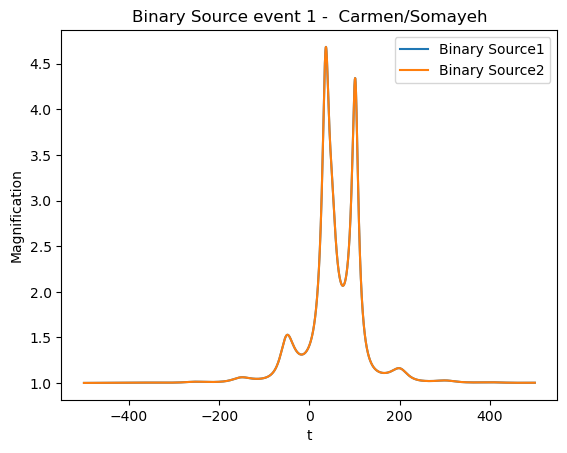

In [10]:
# %matplotlib widget
plt.figure()
plt.plot(t, F_binary2, label='Binary Source1')
plt.plot(t, F_binary2, label='Binary Source2')
# plt.plot(t-t_0, F_cm, label='PSPL')

plt.legend()

plt.ylabel('Magnification')
plt.xlabel('t')
# plt.xlim(40, 60)
plt.title('Binary Source event 1 -  Carmen/Somayeh')
# plt.savefig(path+'CS_5.png')
plt.show()

ValueError: 
f(x)=\begin{cases}3x-6 & x\ge 2\\-3x+6 & x<2\end{cases}
     ^
ParseFatalException: Unknown symbol: \begin, found '\'  (at char 5), (line:1, col:6)

Error in callback <function _draw_all_if_interactive at 0x705c27fc72e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
f(x)=\begin{cases}3x-6 & x\ge 2\\-3x+6 & x<2\end{cases}
     ^
ParseFatalException: Unknown symbol: \begin, found '\'  (at char 5), (line:1, col:6)

ValueError: 
f(x)=\begin{cases}3x-6 & x\ge 2\\-3x+6 & x<2\end{cases}
     ^
ParseFatalException: Unknown symbol: \begin, found '\'  (at char 5), (line:1, col:6)

<Figure size 1000x400 with 2 Axes>

In [11]:
# def Chebyhev_coefficients (df, t0, tE, degree):
#   n = degree
#   event = (df['t'] > t0 - 3*tE) & (df['t'] < t0 + 3*tE)
#   xmin = min(df['t'][event])
#   xmax = max(df['t'][event])
#   bma = 0.5 * (xmax - xmin)
#   bpa = 0.5 * (xmax + xmin)
#   interpoll = interp1d(df['t'],df['A'], kind='cubic')
#   f = [interpoll(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
#   fac = 2.0 / n
#   cheby_coefficients = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n) for k in range(n)]) for j in range(n)]

#   return cheby_coefficients

# def eval (df, t0, tE, cheby_coefficients):

#   Cheby_func = []
#   event = (df['t'] > t0 - 3*tE) & (df['t'] < t0 + 3*tE)
#   xmin = min(df['t'][event])
#   xmax = max(df['t'][event])

#   for t_i in np.sort(df['t'][event].values):

#     y = (2.0 * t_i - xmin - xmax) * (1.0 / (xmax - xmin))
#     y2 = 2.0 * y
#     (d, dd) = (cheby_coefficients[-1], 0)             # Special case first step for efficiency

#     for cj in cheby_coefficients[-2:0:-1]:            # Clenshaw's recurrence
#       (d, dd) = (y2 * d - dd + cj, d)
#     Cheby_func.append(y * d - dd + 0.5 * cheby_coefficients[0])

#   Cheby_func = np.asarray(Cheby_func)
#   return Cheby_func

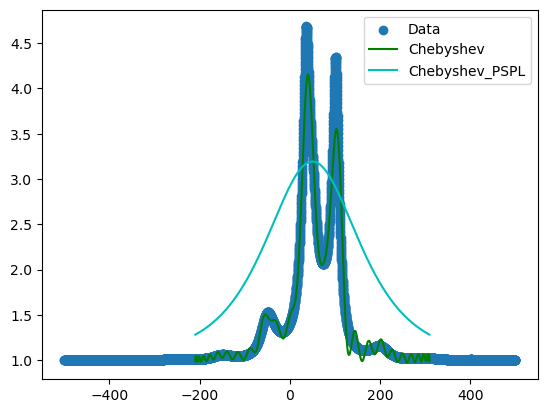

In [19]:
df = pd.DataFrame({'t':t, 'A':F_binary2, 'A_err':np.ones_like((t))*0.01})
nll = lambda *args: -lnlike(*args)
res_scipy = op.minimize(nll,
                        [t_0, t_E, u_0, f_s],
                        args=(df.t.values,
                              df.A.values,
                              df.A_err.values),
                              method = 'Nelder-Mead')

t0_ml, tE_ml, u0_ml, fs_ml = res_scipy['x']
df_PSPL= pd.DataFrame({'t':t,
                       'A':fun_PSPL(t, t0_ml, tE_ml, u0_ml, fs_ml),
                       'A_err':np.ones_like((t))*0.01})


degree = 50

coeff = Chebyhev_coefficients (df, t_0, t_E, degree)
coeff_PSPL = Chebyhev_coefficients (df_PSPL, t0_ml, tE_ml, degree)

cheby_func = evaluate_chebyshev(df, t_0, t_E, coeff)
cheby_func_PSPL = evaluate_chebyshev(df_PSPL, t_0, t_E, coeff_PSPL)

event = (df['t'] > t_0 - 3*t_E) & (df['t'] < t_0 + 3*t_E)
event_PSPL = (df_PSPL['t'] > t_0 - 3*t_E) & (df_PSPL['t'] < t_0 + 5*t_E)

plt.scatter(df['t'], df['A'], label='Data')
plt.plot(df['t'][event], cheby_func, 'g-', label='Chebyshev')
plt.plot(df_PSPL['t'][event], cheby_func_PSPL, 'c-', label='Chebyshev_PSPL')

plt.legend()


In [ ]:
event = (df['t'] > t_0 - 3*t_E) & (df['t'] < t_0 + 3*t_E)
event_PSPL = (df_PSPL['t'] > t_0 - 3*t_E) & (df_PSPL['t'] < t_0 + 5*t_E)

plt.scatter(df['t'], df['A'], label='Data')
plt.plot(df['t'][event], cheby_func, 'g-', label='Chebyshev')
plt.plot(df_PSPL['t'][event], cheby_func_PSPL, 'c-', label='Chebyshev_PSPL')

plt.legend()


In [15]:
np.sum((cheby_func_PSPL-cheby_func)**2)

np.float64(1771.6072314411367)